In [4]:
import keras
import tensorflow as tf
import numpy as np
import scipy
from tqdm import tqdm
import matplotlib.pyplot as plt
try:
  from netCDF4 import Dataset
except:
  !pip install netCDF4
  from netCDF4 import Dataset
import datetime as dt
try:
  import cartopy.crs as ccrs
except:
  !pip install cartopy
  import cartopy.crs as ccrs
from joblib import Parallel, delayed


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 34.9 MB/s eta 0:00:00


### Download Data

In [ ]:
!wget https://zenodo.org/records/20159662/files/collocated_dataset.nc?download=1
!wget https://zenodo.org/records/20159662/files/BHIST.f09_g17.coupled_nature.cam.h1.201001-201012.nc?download=1
!wget https://zenodo.org/records/20159662/files/domain.lnd.fv0.9x1.25_gx1v7.151020.nc?download=1

In [ ]:
nc_domain = Dataset('domain.lnd.fv0.9x1.25_gx1v7.151020.nc')
lon = np.array(nc_domain['xc'][:])
lat = np.array(nc_domain['yc'][:])

In [ ]:
nc = Dataset('collocated_dataset.nc')
time = np.array(nc['YYYYMMDDHH'][:])
cldliq = np.array(nc['CLDLIQ'][:])
cldice = np.array(nc['CLDICE'][:])
swndr = np.array(nc['a2x1hi_Faxa_swndr'][:])
swvdr = np.array(nc['a2x1hi_Faxa_swvdr'][:])
swndf = np.array(nc['a2x1hi_Faxa_swndf'][:])
swvdf = np.array(nc['a2x1hi_Faxa_swvdf'][:])

In [ ]:
nc_sza = Dataset('BHIST.f09_g17.coupled_nature.cam.h1.201001-201012.nc')
date_sza = np.array(nc_sza['date'][:])
datesec_sza = np.array(nc_sza['datesec'][:])
time_sza = []
for i in range(date_sza.shape[0]):
    month = int(str(date_sza[i])[4:6])
    day = int(str(date_sza[i])[6:])
    hour = int(datesec_sza[i]/3600)
    time_sza.append('2011-{:02d}-{:02d}-{:02d}'.format(month, day, hour))
time_sza = np.array(time_sza)

C:\Users\josep\AppData\Local\Temp\ipykernel_13052\3252438597.py:11: RuntimeWarning: divide by zero encountered in log10
  ax.pcolormesh(lon, lat, np.log10(swndf[0, index_time, :, :]), transform = ccrs.PlateCarree())


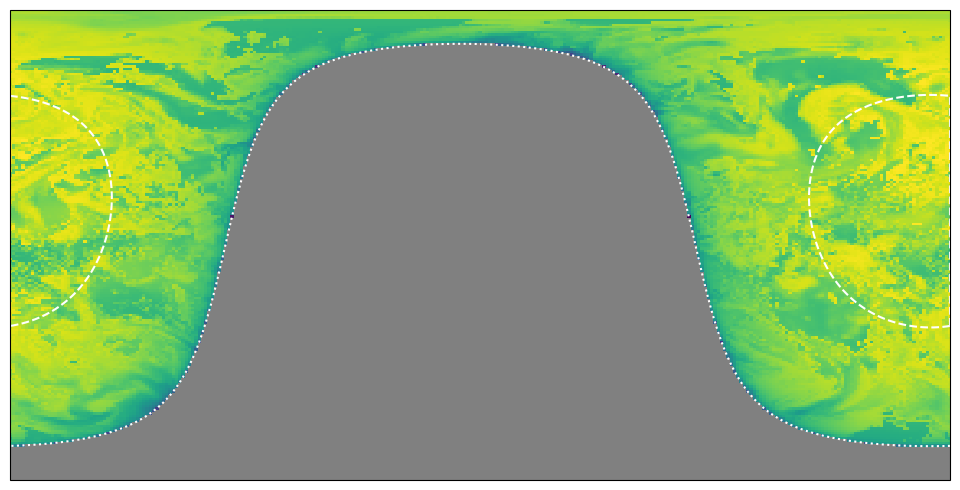

In [ ]:
sza = np.zeros((time.shape[0], 192, 288))
for i in range(time.shape[0]):
    idt = np.where(time_sza == time[i])[0][0]
    sza1 = np.array(nc_sza['SZA'][idt, :, :])
    sza2 = np.array(nc_sza['SZA'][idt+1, :, :])
    sza[i, :, :] = (sza1 + sza2) * 0.5

index_time = 20
fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_facecolor('gray')
ax.pcolormesh(lon, lat, np.log10(swndf[0, index_time, :, :]), transform = ccrs.PlateCarree())
ax.contour(lon, lat, sza[index_time, :, :], levels = [0, 45, 90], linestyles = ['-', '--', ':'], colors = ['white'], transform = ccrs.PlateCarree())

In [ ]:
index_time = 0

for i in range(10):
    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swndr[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swndr_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swvdr[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swvdr_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swndf[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swndf_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

    fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
    ax.set_facecolor('gray')
    im = ax.pcolormesh(lon, lat, swvdf[i, index_time, :, :], cmap = 'gist_ncar', vmin = 0, vmax = 450, transform = ccrs.PlateCarree())
    cbar = plt.colorbar(im, shrink = 0.7)
    fig.savefig('swvdf_{:02d}.png'.format(i+1), bbox_inches = 'tight')
    plt.close()

fig, ax = plt.subplots(1, 1, figsize = (10, 5), tight_layout = True, subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_facecolor('gray')
im = ax.pcolormesh(lon, lat, sza[index_time, :, :], cmap = 'viridis', vmin = 0, transform = ccrs.PlateCarree())
cs = ax.contour(lon, lat, sza[index_time, :, :], levels = [0, 30, 60, 90], linestyles = ['--', '-.', ':',  '-'], colors = ['white'], transform = ccrs.PlateCarree())
ax.clabel(cs, levels = [0, 30, 60, 90], inline = True)
cbar = plt.colorbar(im, shrink = 0.7)
fig.savefig('sza.png'.format(i+1), bbox_inches = 'tight')

In [ ]:
idx_valid = np.where(sza < 90, True, False) * np.where(np.std(swndr, axis = 0) > 1e-2, True, False) * np.where(np.std(swvdr, axis = 0) > 1e-2, True, False) * np.where(np.std(swndf, axis = 0) > 1e-2, True, False) * np.where(np.std(swvdf, axis = 0) > 1e-2, True, False)
n_sample = np.count_nonzero(idx_valid)
print(n_sample)

swndr_valid = swndr[:, idx_valid]
swvdr_valid = swvdr[:, idx_valid]
swndf_valid = swndf[:, idx_valid]
swvdf_valid = swvdf[:, idx_valid]
sw_valid = np.stack((swndr_valid, swvdr_valid, swndf_valid, swvdf_valid), axis = 0)

def task_cov(idx, data, eps = 1e-6):
    '''
    Compute square-root of covariance matrix
    COV = U @ S^0.5 @ S^0.5 @ U.T
    U: singular vectors
    S: singular values
    data: [n_variable, n_ensemble, n_sample]
    label: [4 square-root of singular values, 16 elements of the U matrix matrix]
    '''
    cov = np.cov(data[:, :, idx], ddof = 1) + eps * np.eye(data.shape[0])
    u, s, _ = scipy.linalg.svd(cov)
    return np.concatenate((np.sqrt(s), u.flatten()), axis = 0), idx


Y = np.zeros((n_sample, 20))
results = Parallel(n_jobs = 10)(
    delayed(task_cov)(i, sw_valid) for i in range(n_sample)
)
for label, idx in results:
    Y[idx, :] = label

1926983


In [ ]:
sw_mean = np.mean(sw_valid, axis = 1)
sza_valid = sza[idx_valid]
X = np.concatenate((sw_mean.T, sza_valid.reshape(-1, 1)), axis = -1)
print(X.shape)

(1926983, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)

scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

'''
scaler_Y = StandardScaler()
Y_train_scaled = scaler_Y.fit_transform(Y_train)
Y_test_scaled = scaler_Y.transform(Y_test)
'''

(1348888, 5)
(578095, 5)
(1348888, 20)


'\nscaler_Y = StandardScaler()\nY_train_scaled = scaler_Y.fit_transform(Y_train)\nY_test_scaled = scaler_Y.transform(Y_test)\n'

In [ ]:
def orthogonal_process_layer(raw_output):
    # 1. Slice the tensor (Assuming shape is [Batch, 20])
    s_raw = raw_output[:, :4]   # First 4: Log of sqrt singular values (assumed)
    u_raw = raw_output[:, 4:]   # Last 16: Raw matrix elements

    # 2. Constrain Singular Values to be positive
    # Using exp assumes the network is predicting log(sqrt singular values)
    s_constrained = tf.exp(s_raw)

    # 3. Orthogonalize the Vector elements
    # Reshape 16 elements to a 4x4 matrix
    u_matrix = tf.reshape(u_raw, [-1, 4, 4])

    # Apply QR
    q, r = tf.linalg.qr(u_matrix)

    # Fix sign ambiguity using the diagonal of R
    diag_r = tf.linalg.diag_part(r)
    sign_corrector = tf.sign(diag_r)[:, tf.newaxis, :]
    u_orthogonal_matrix = q * sign_corrector

    # Flatten back to 16 elements
    u_flat = tf.reshape(u_orthogonal_matrix, [-1, 16])

    # 4. Merge back to a 20-element vector
    combined = tf.concat([s_constrained, u_flat], axis=1)

    return combined


In [ ]:
model = keras.Sequential()
model.add(keras.Input(shape = (5, )))
model.add(keras.layers.Dense(units = 10, activation=keras.activations.relu))
model.add(keras.layers.Dense(units = 20, activation=keras.activations.relu))
model.add(keras.layers.Dense(units = 40, activation=keras.activations.relu))
model.add(keras.layers.Dense(units = 20, activation = keras.activations.linear))
model.add(keras.layers.Lambda(orthogonal_process_layer))

In [ ]:
def vec_to_us(vec, k=4):
    '''
    vec: [batch_size, output_size]
    '''
    batch_size = tf.shape(vec)[0]
    s = vec[:, :4]**2
    u = tf.reshape(vec[:, 4:], (batch_size, k, k))
    return u, s


def kl_divergence(u1, s1, u2, s2, k = 4):
    """
    KL divergence D_KL(N(0, Σ1) || N(0, Σ2))
    where Σ1 = (u1 @ s1^0.5) @ (u1 @ s1^0.5).T and Σ2 = (u2 @ s2^0.5) @ (u2 @ s2^0.5).T

    Args:
        u1, u2: [batch, k, k] singular vector matrix
        s1, s2: [batch, k] singular values

    Returns:
        KL divergence per batch: [batch]
    """

    # Log determinant: Determinants are simply product of singular values
    logdet1 = tf.math.log(tf.reduce_prod(s1, axis = -1))
    logdet2 = tf.math.log(tf.reduce_prod(s2, axis = -1))
    logdet_term = logdet2 - logdet1

    # Trace term: easy to compute inverse since we know orthogonal transformation
    S2_i = (u2 * 1/s2[:, None, :]) @ tf.transpose(u2, perm = [0, 2, 1])
    S1 = (u1 * s1[:, None, :]) @ tf.transpose(u1, perm = [0, 2, 1])
    trace_term = tf.linalg.trace(S2_i @ S1)

    kl = 0.5 * (trace_term - k + logdet_term)

    return kl

def kl_loss(y_true, y_pred):
    u1, s1 = vec_to_us(y_true)
    u2, s2 = vec_to_us(y_pred)
    kl = kl_divergence(u1, s1, u2, s2)
    return tf.reduce_mean(kl)


In [ ]:
k = 4
batch = 10

vec_size = 20

y_true = tf.convert_to_tensor(Y_train[0:10, :])
y_pred = tf.convert_to_tensor(Y_train[100:110, :])

u1, s1 = vec_to_us(y_true)
u2, s2 = vec_to_us(y_pred)

# Log determinant: Determinants are simply product of singular values
logdet1 = tf.math.log(tf.reduce_prod(s1, axis = -1))
logdet2 = tf.math.log(tf.reduce_prod(s2, axis = -1))
logdet_term = logdet2 - logdet1
print(logdet_term.numpy())

# Trace term: easy to compute inverse since we know orthogonal transformation
S2_i = (u2 * 1/s2[:, None, :]) @ tf.transpose(u2, perm = [0, 2, 1])
S1 = (u1 * s1[:, None, :]) @ tf.transpose(u1, perm = [0, 2, 1])
trace_term = tf.linalg.trace(S2_i @ S1)

kl = 0.5 * (trace_term - k + logdet_term)
print(kl.numpy())

loss_fn = kl_loss(y_true, y_pred)
print(loss_fn.numpy())

[-25.46113432  26.53074236  -2.94726992  -4.14076145   5.24632451
   1.72259826 -22.50773453 -10.96810473  -6.6369672  -18.43638185]
[6.34652812e+04 1.12817589e+01 7.57973526e+00 4.52666487e+01
 7.30035662e+00 2.51491709e+01 1.39154862e+05 5.32228437e+01
 4.14008361e+02 5.89321206e+03]
20907.716369727343


In [ ]:
model.compile(optimizer=tf.optimizers.Adam(learning_rate = 0.001),
              loss = kl_loss)
model.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_4 (Dense)              (None, 10)                60        
_________________________________________________________________
dense_5 (Dense)              (None, 20)                220       
_________________________________________________________________
dense_6 (Dense)              (None, 40)                840       
_________________________________________________________________
dense_7 (Dense)              (None, 20)                820       
_________________________________________________________________
lambda (Lambda)              (None, 20)                0         
Total params: 1,940
Trainable params: 1,940
Non-trainable params: 0
_________________________________________________________________


In [ ]:
history = model.fit(
    x = X_train_scaled,
    y = Y_train,
    batch_size = 32,
    epochs = 10,
    validation_split = 0.1,
    shuffle = True,
)

Epoch 1/10
37938/37938 [==============================] - 183s 5ms/step - loss: 5.6566 - val_loss: 2.1873
Epoch 2/10
37938/37938 [==============================] - 137s 4ms/step - loss: 2.0544 - val_loss: 1.9695
Epoch 3/10
37938/37938 [==============================] - 155s 4ms/step - loss: 1.9942 - val_loss: 1.9063
Epoch 4/10
37938/37938 [==============================] - 158s 4ms/step - loss: 1.9594 - val_loss: 1.8980
Epoch 5/10
37938/37938 [==============================] - 158s 4ms/step - loss: 1.9237 - val_loss: 1.8640
Epoch 6/10
37938/37938 [==============================] - 153s 4ms/step - loss: 1.9095 - val_loss: 1.8966
Epoch 7/10
37938/37938 [==============================] - 162s 4ms/step - loss: 1.8921 - val_loss: 1.7969
Epoch 8/10
37938/37938 [==============================] - 159s 4ms/step - loss: 1.8791 - val_loss: 1.8116
Epoch 9/10
37938/37938 [==============================] - 169s 4ms/step - loss: 1.8662 - val_loss: 1.8537
Epoch 10/10
37938/37938 [=====================

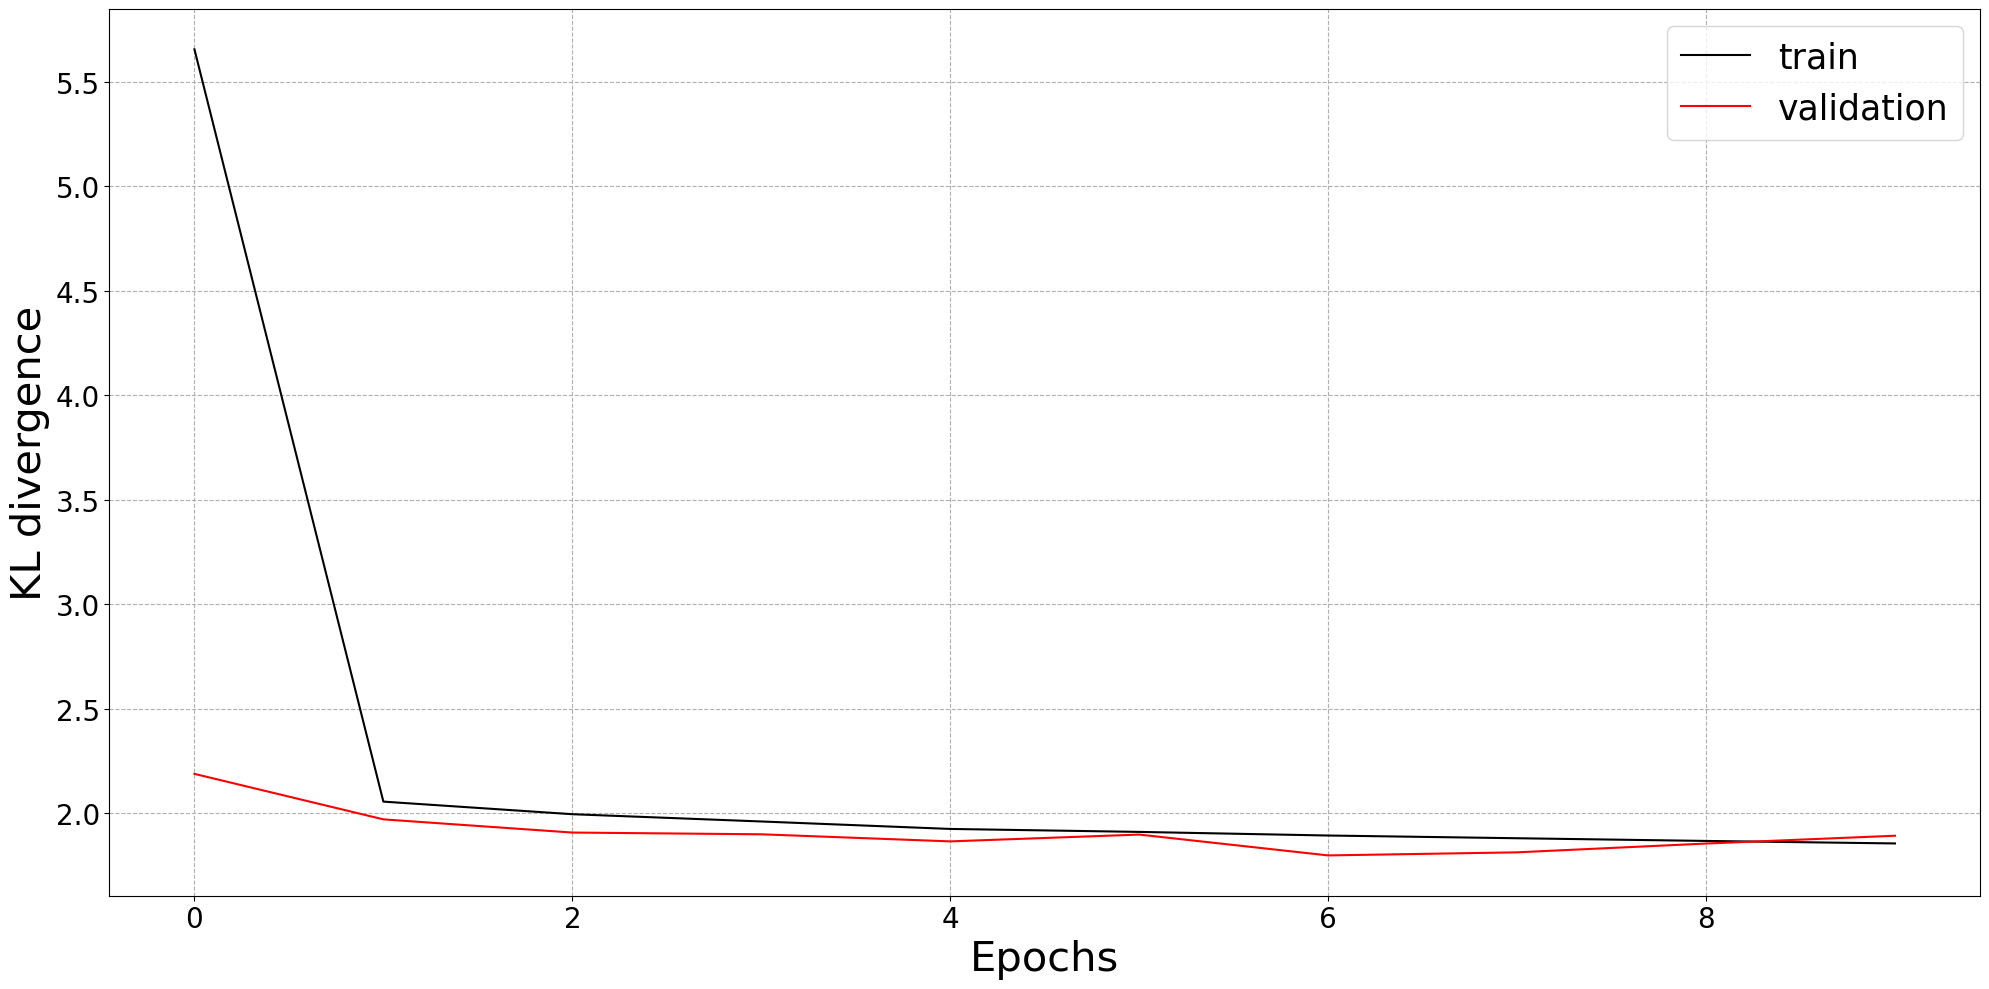

In [ ]:
fig, ax = plt.subplots(1, 1, figsize = (20, 10), tight_layout = True)
ax.plot(history.history['loss'], c = 'black', label = 'train')
ax.plot(history.history['val_loss'], c = 'red', label = 'validation')
ax.set_xlabel('Epochs', fontsize = 30)
ax.set_ylabel('KL divergence', fontsize = 30)
ax.grid(axis = 'both', linestyle = '--')
ax.tick_params(axis = 'both', labelsize = 20)
ax.legend(loc = 'upper right', fontsize = 25)

In [ ]:
Y_pred = model.predict(X_test_scaled)
print(Y_pred.shape)

(578095, 20)


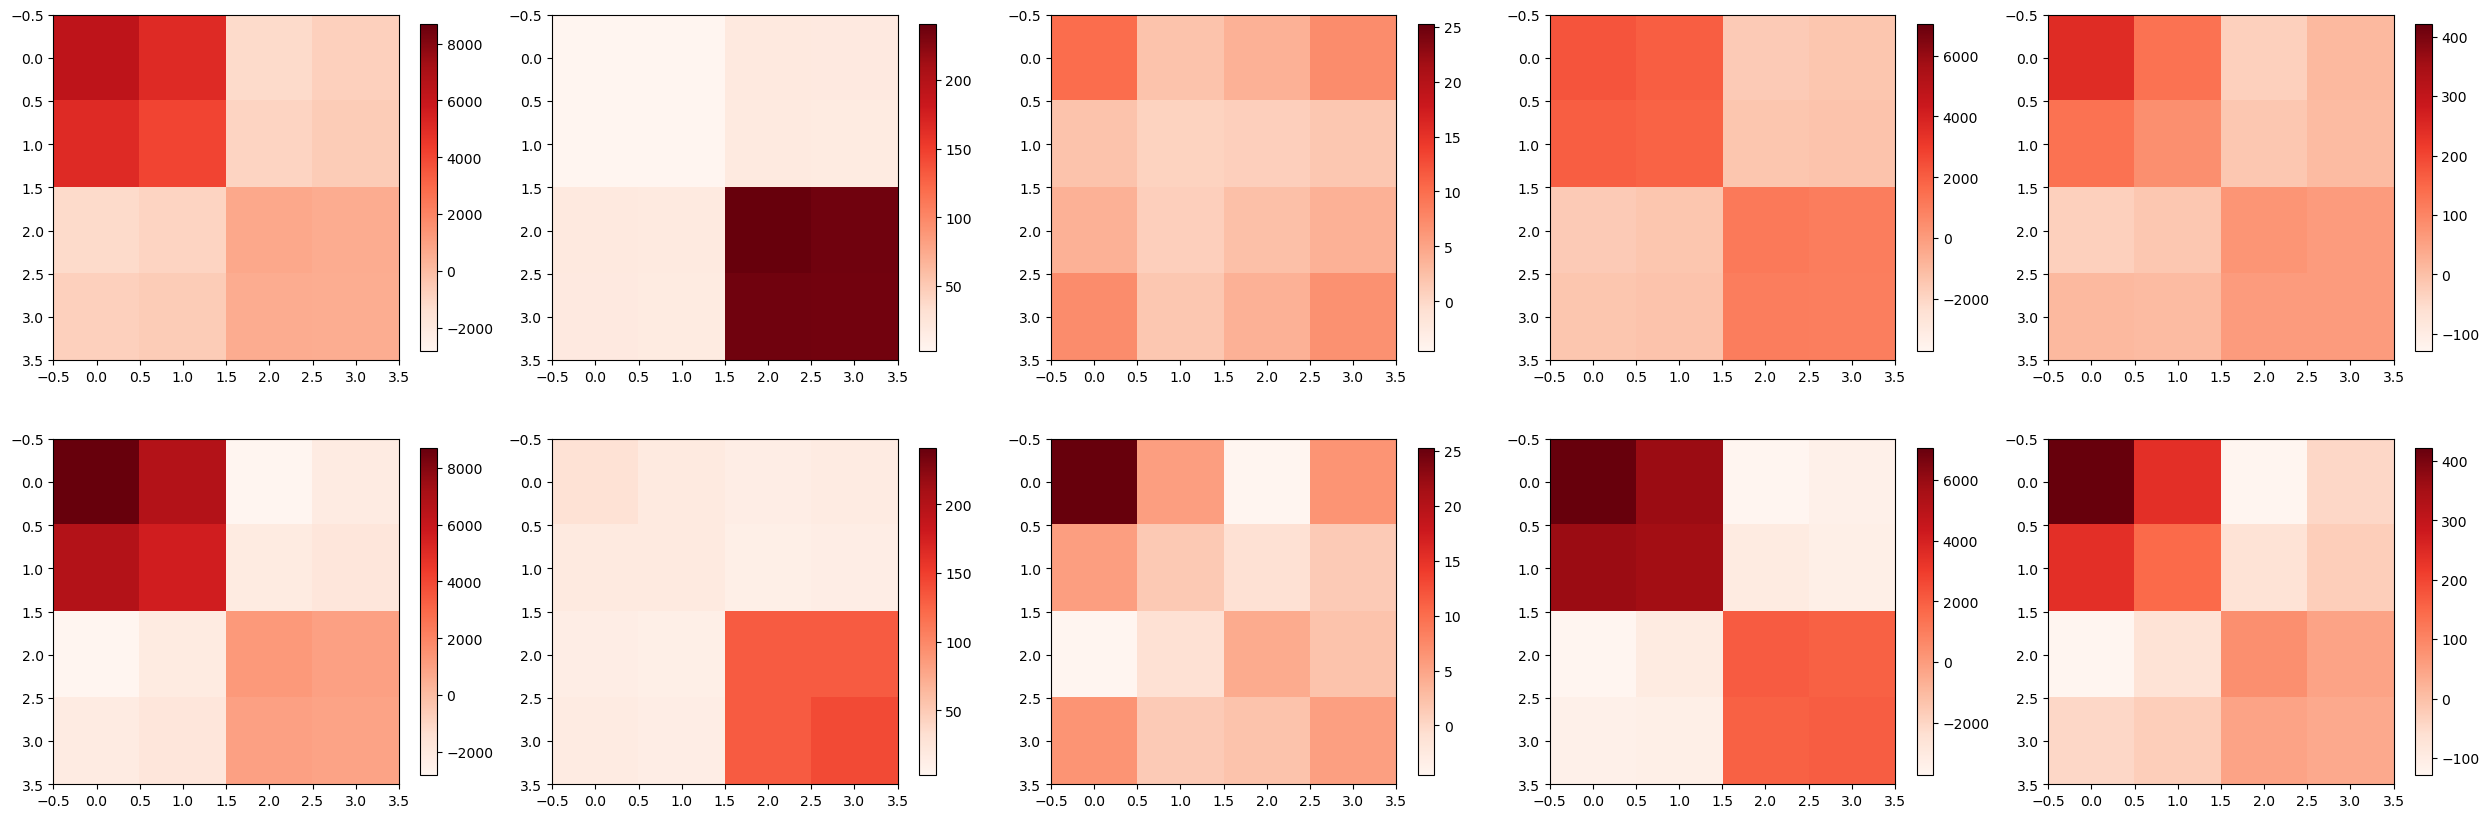

In [ ]:

fig, ax = plt.subplots(5, 2, figsize = (10, 25), tight_layout = True)
for i in range(5):
    s_test = Y_test[100*i, :4]**2
    u_test = Y_test[100*i, 4:].reshape((4, 4))
    cov_test = (u_test * s_test[None, :]) @ u_test.T

    s_pred = Y_pred[100*i, :4]**2
    u_pred = Y_pred[100*i, 4:].reshape((4, 4))
    cov_pred = (u_pred * s_pred[None, :]) @ u_pred.T

    vmin = min(np.min(cov_test), np.min(cov_pred))
    vmax = max(np.max(cov_test), np.max(cov_pred))

    im = ax[i, 0].imshow(cov_test, cmap = 'Reds', vmin = vmin, vmax = vmax)
    cbar = plt.colorbar(im, ax = ax[0, i], shrink = 0.6)
    im = ax[i, 1].imshow(cov_pred, cmap = 'Reds', vmin = vmin, vmax = vmax)
    cbar = plt.colorbar(im, ax = ax[1, i], shrink = 0.6)

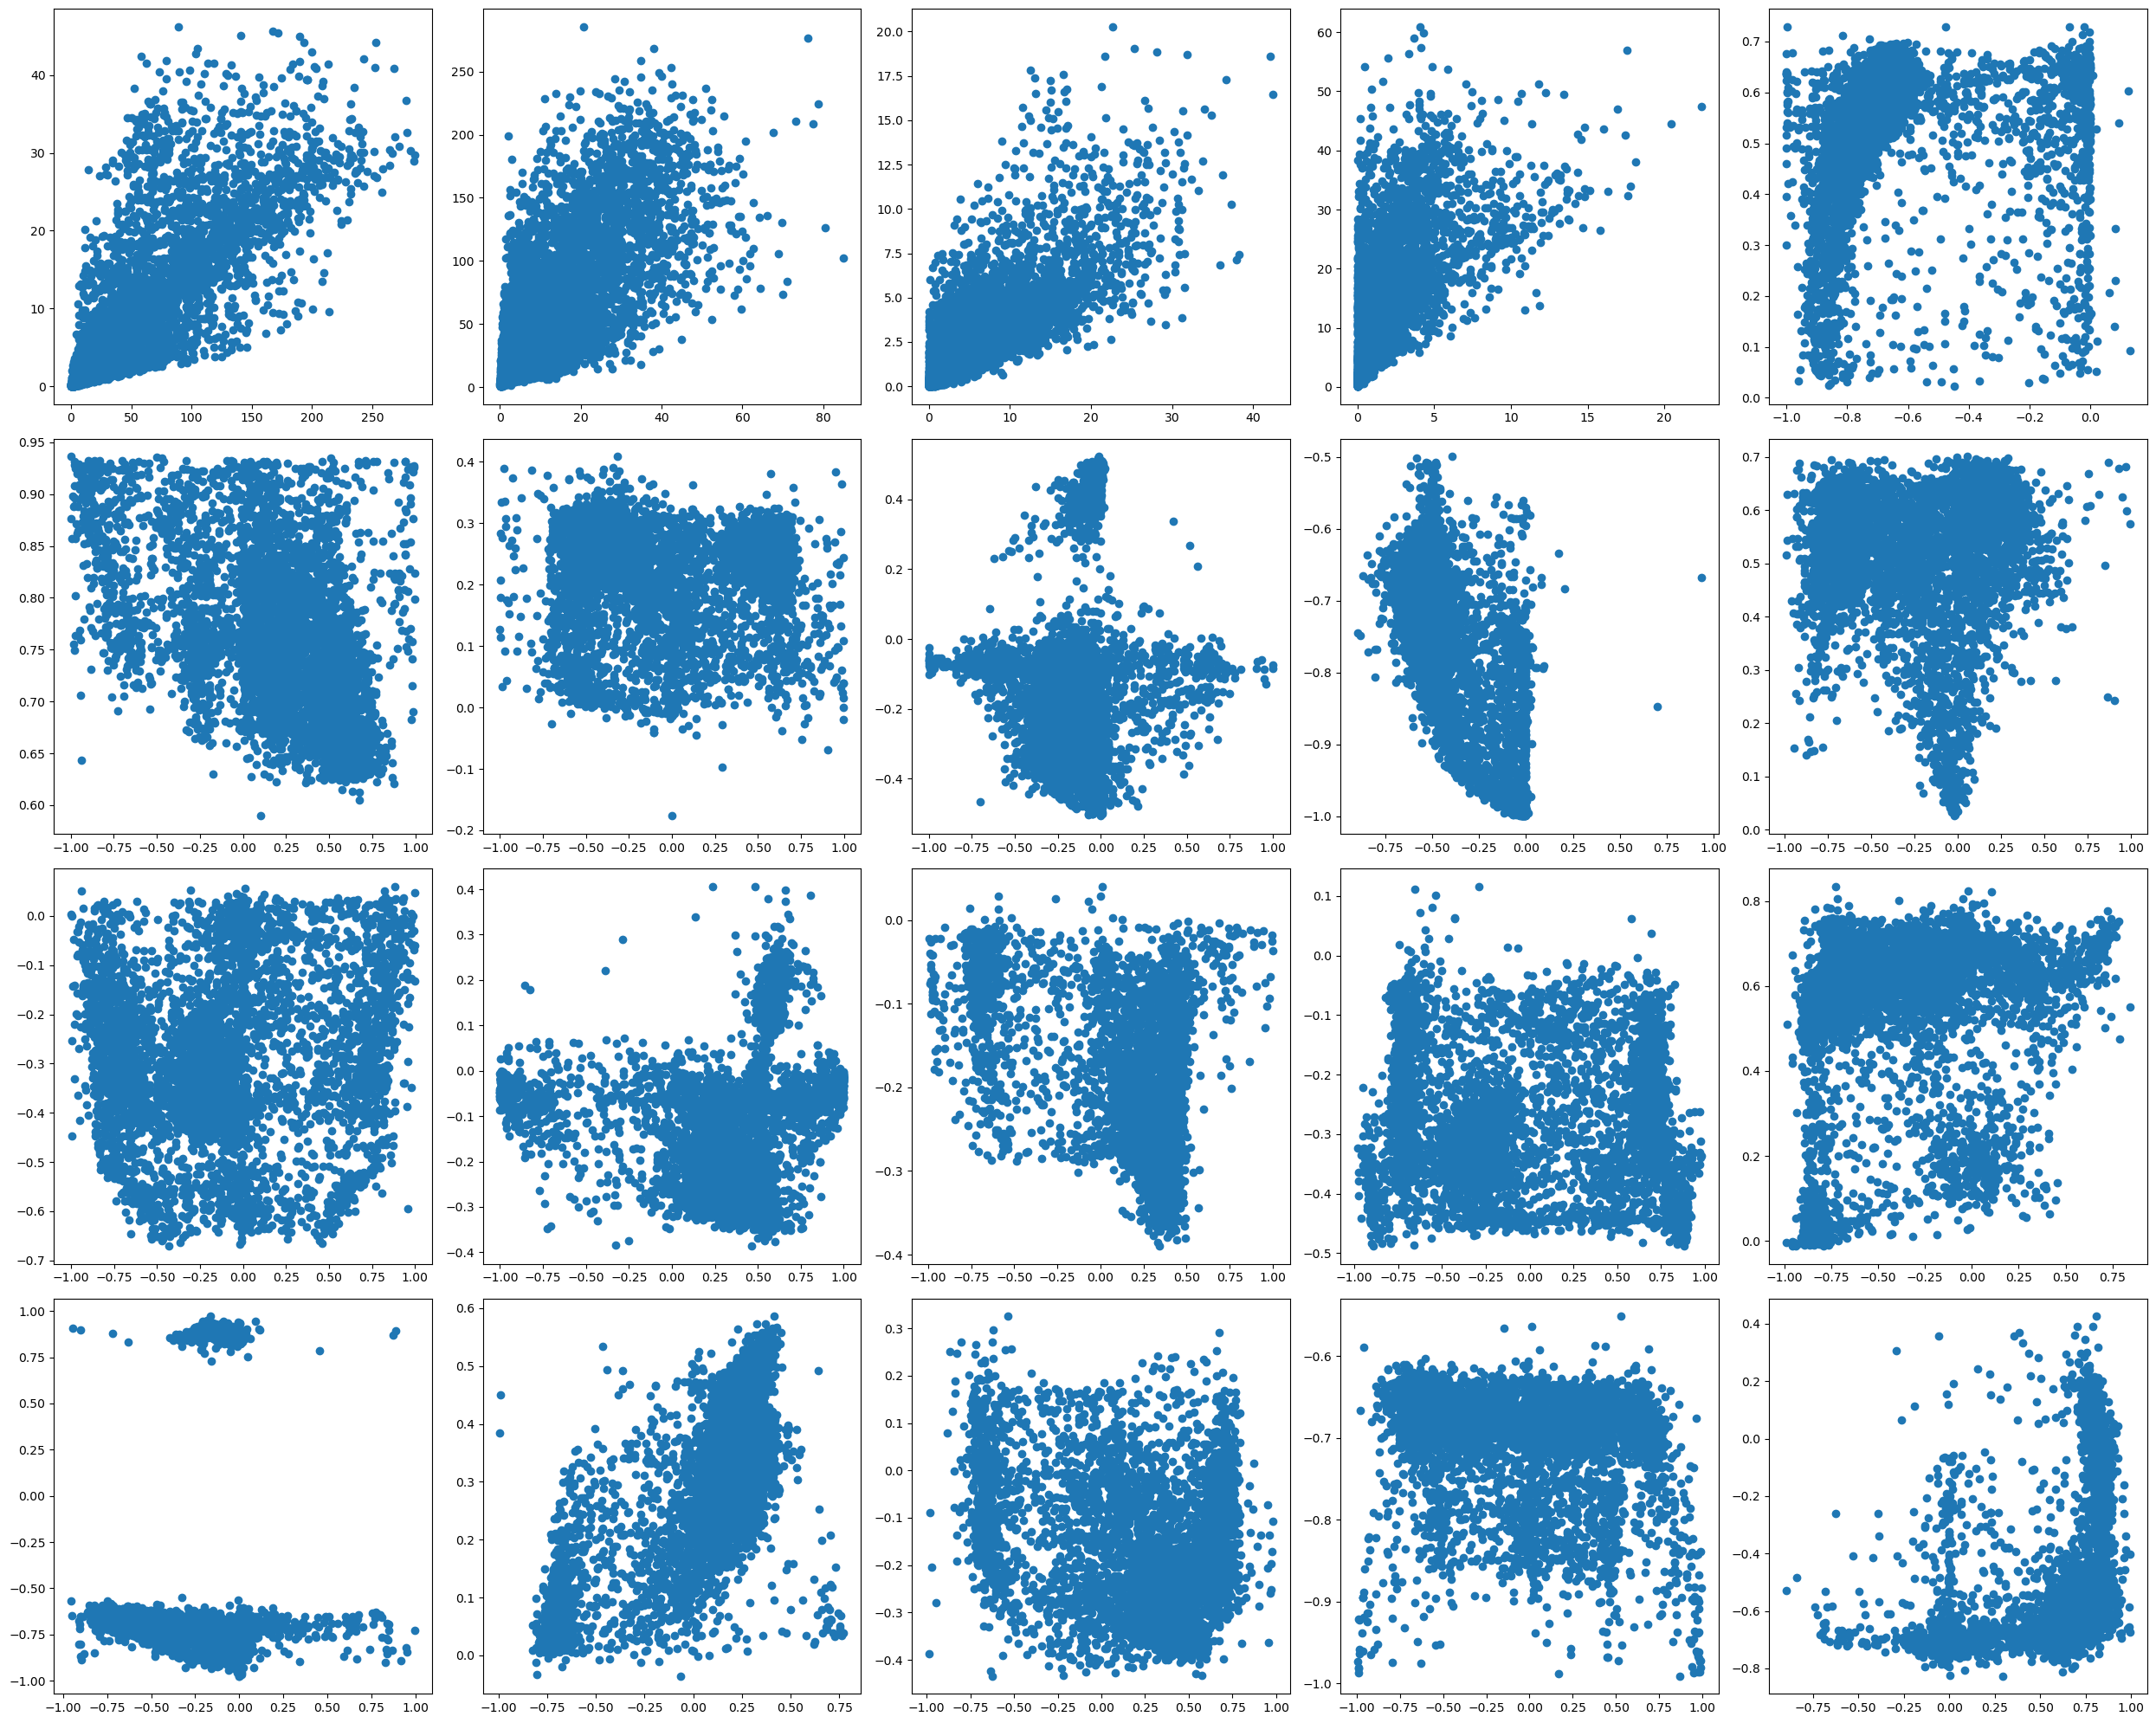

In [ ]:
fig, ax = plt.subplots(4, 5, figsize = (25, 20), tight_layout = True)
for i in range(4):
    for j in range(5):
        index = 5*i+j
        ax[i, j].scatter(Y_test[:5000, index],Y_pred[:5000, index])